# EDA for house prices

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import statsmodels.api as sm
# Ignoring all future warnings
warnings.filterwarnings('ignore', category = FutureWarning)

In [3]:
data = pd.read_csv("train.csv")
data.drop(columns = "Id", inplace = True)
data.sample(5)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
414,60,RL,59.0,11228,Pave,NaN,IR2,Lvl,AllPub,CulDSac,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,228000
453,60,FV,75.0,9000,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,210000
1021,20,RL,64.0,7406,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,7,2006,New,Partial,194000
318,60,RL,90.0,9900,Pave,NaN,Reg,Low,AllPub,Inside,...,0,NaN,NaN,NaN,0,4,2009,WD,Normal,260000
620,30,RL,45.0,8248,Pave,Grvl,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,67000


In [4]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0
BsmtFinSF2,1460.0,46.549315,161.319273,0.0,0.00,0.0,0.00,1474.0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

## Checking the distribution of the target

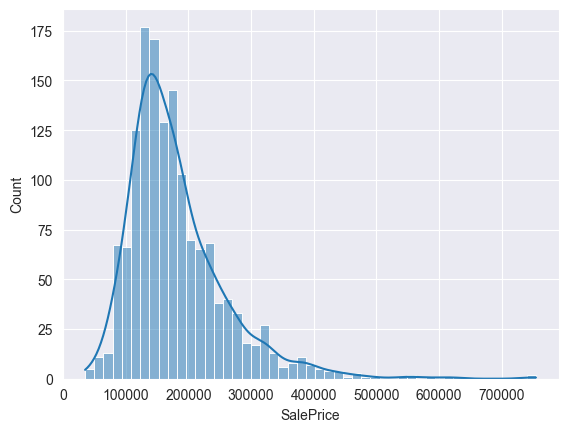

In [6]:
sns.histplot(x = "SalePrice", data = data, kde = True)
plt.show()

Seems like the feature is right skewed, suggesting expensive houses are less in number.

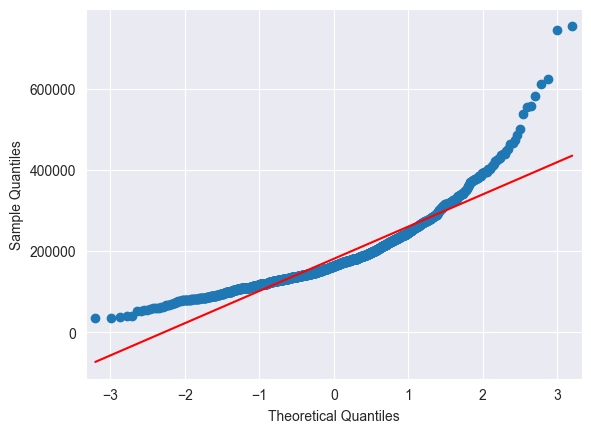

In [7]:
sm.qqplot(data["SalePrice"], line = "s", linewidth = 2)
plt.show()

Maybe log transform will help us. will do it later. So we have to **Log Transform the target** Later

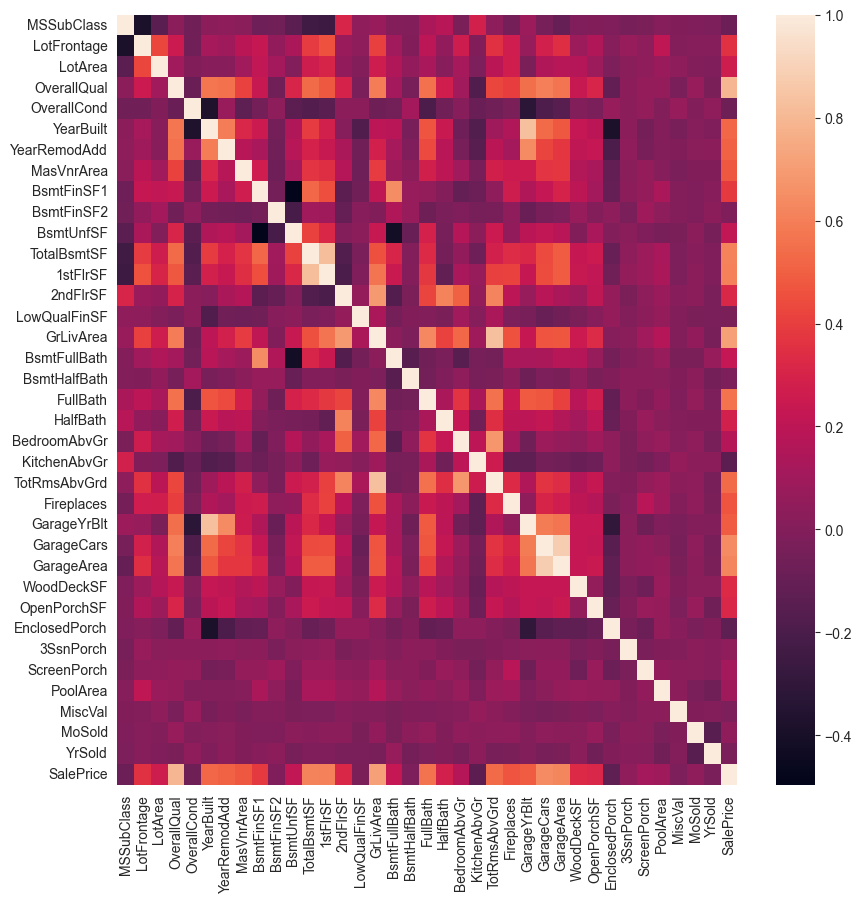

In [8]:
plt.figure(figsize=(10,10))
sns.heatmap(data.select_dtypes(exclude = "object").corr())
plt.show()

seems like features like GrLivArea, OverallQual, GarageCars, GarageArea, FullBath, etc are the features that affect it a lot.
Lets make a hypothesis.

**GrLiveArea affects the SalePrice and is predictive in predicting SalePrice.**

Now Lets test it!

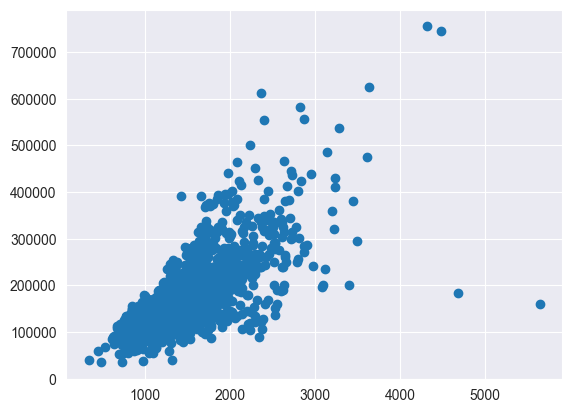

In [9]:
plt.scatter(data["GrLivArea"], data["SalePrice"])
plt.show()

uhmm.... lets look at the distribution a bit

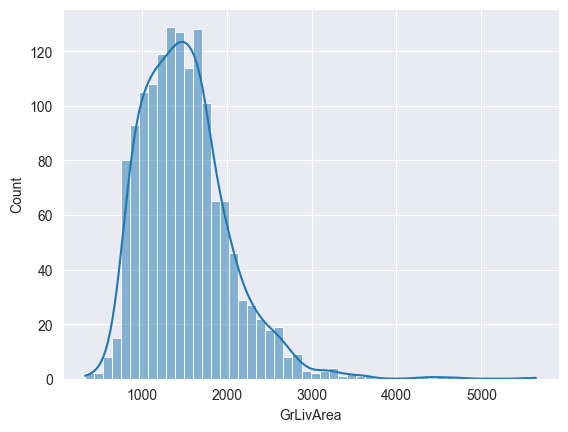

np.float64(1.3665603560164552)

In [10]:
sns.histplot(data["GrLivArea"], bins = 50, kde = True)
plt.show()
data["GrLivArea"].skew()

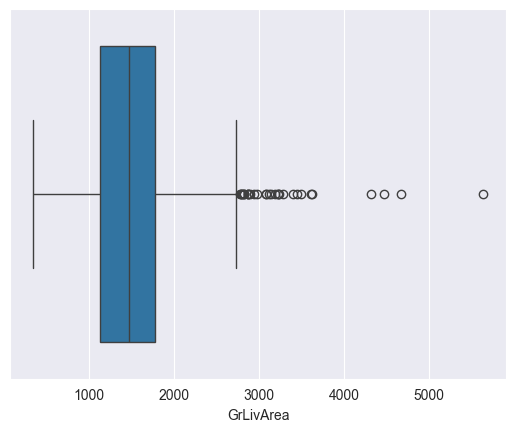

In [11]:
sns.boxplot(x = "GrLivArea", data = data)
plt.show()

seems like there is a skew and a bit of outliers. lets reduce it with a log transform magic. there are even huge houses with area around 3500-5700. these pretty much seem like huge houses the errors. also the data is concentrated in the middle.

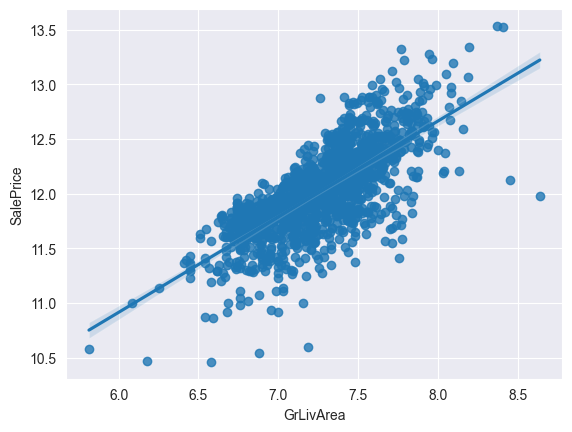

In [12]:
data[["GrLivArea","SalePrice"]] = np.log1p(data[["GrLivArea","SalePrice"]])
sns.regplot(x = "GrLivArea", y = "SalePrice", data = data)
plt.show()


Seems like it is indeed predective! just needed to use those log transforms. lets see its correlation with other features

In [13]:
data.select_dtypes(exclude = "object").corr()["GrLivArea"].drop(index = "GrLivArea").sort_values(ascending = False)

TotRmsAbvGrd     0.825521
SalePrice        0.730254
2ndFlrSF         0.662944
FullBath         0.653167
OverallQual      0.614207
1stFlrSF         0.551440
BedroomAbvGr     0.538848
GarageCars       0.496126
GarageArea       0.476164
Fireplaces       0.468924
TotalBsmtSF      0.435860
HalfBath         0.430454
LotFrontage      0.366469
MasVnrArea       0.363743
OpenPorchSF      0.320793
YearRemodAdd     0.311456
BsmtUnfSF        0.268192
GarageYrBlt      0.254821
LotArea          0.245373
WoodDeckSF       0.240979
YearBuilt        0.235500
BsmtFinSF1       0.163931
KitchenAbvGr     0.111909
PoolArea         0.109771
LowQualFinSF     0.108151
ScreenPorch      0.105955
MSSubClass       0.081715
MoSold           0.066083
3SsnPorch        0.033086
BsmtFullBath     0.020664
EnclosedPorch    0.003328
MiscVal         -0.010049
BsmtFinSF2      -0.012766
BsmtHalfBath    -0.017873
YrSold          -0.030975
OverallCond     -0.101960
Name: GrLivArea, dtype: float64

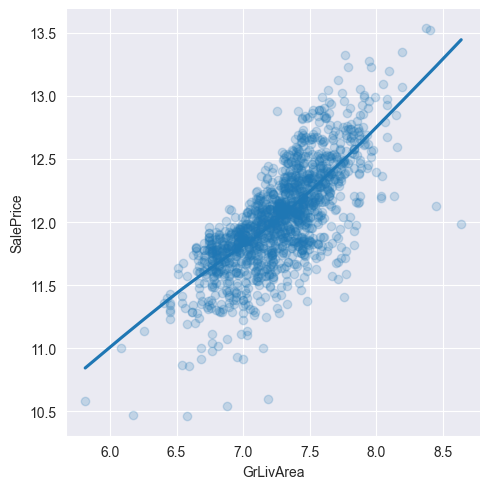

In [14]:
sns.lmplot(x="GrLivArea", y="SalePrice", data=data, lowess=True, scatter_kws={'alpha':0.2})

so this is feature is indeed correlated. Next lets see overall qual.

In [16]:
data["OverallQual"].value_counts()

OverallQual
5     397
6     374
7     319
8     168
4     116
9      43
3      20
10     18
2       3
1       2
Name: count, dtype: int64

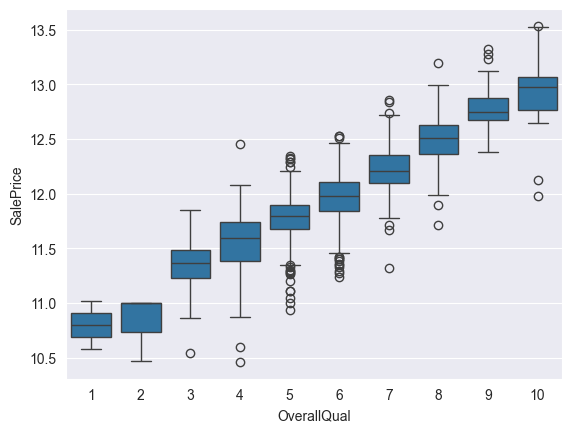

In [15]:
sns.boxplot(x = "OverallQual", y = "SalePrice", data = data)
plt.show()

seems the data is predictive but imbalnced. lets do target mean encoding.

In [24]:
data["OverallQual"] = data["OverallQual"].map(data.select_dtypes(exclude = 'object').groupby("OverallQual").mean()["SalePrice"])
data["OverallQual"], data["OverallQual"].corr(data["SalePrice"])

(0       12.221778
 1       11.967315
 2       12.221778
 3       12.221778
 4       12.497195
           ...    
 1455    11.967315
 1456    11.967315
 1457    12.221778
 1458    11.780665
 1459    11.780665
 Name: OverallQual, Length: 1460, dtype: float64,
 np.float64(0.8206015090940791))

great! now lets see who is next on the list to be tested.


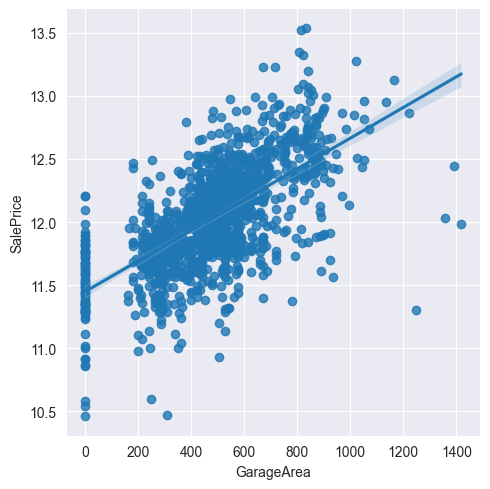

In [31]:
sns.lmplot(x = "GarageArea", y = "SalePrice", data = data)
plt.show()